In [1]:
import pennylane as qml
from pennylane import numpy as np

## Why dynamic circuits

Mid-circuit measurements (MCMs), i.e. measurements in the middle of a quantum circuit, unlock new possibilities due to the flexibility they offer.
This flexibility allows for the implementation of algorithms that rely on intermediate results, enables the optimization of qubit usage, and proves particularly valuable in areas like error correction codes, among other applications

## Mid-circuit measurements

In PennyLane, mid-circuit measurements in the *computational basis* can be performed using `qml.measure()`.

By setting `reset=True`, we can reutilize a measured qubit.
This action resets the corresponding wire to the $\ket{0}$ state

/var/folders/ch/tk2fv32j3tg_jm9mf_b7rpbr0000gn/T/ipykernel_4485/2183676328.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


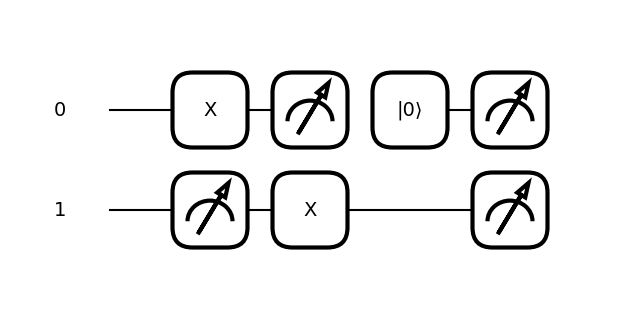

In [2]:
dev = qml.device("default.qubit", wires=2)

@qml.qnode(dev)
def circ1():
    qml.X(0)
    m_0 = qml.measure(0, reset=True) #mid-circuit measurement and reset on wire 0
    m_1 = qml.measure(1, reset=False) #mid-circuit measurement on wire 2 and no reset
    qml.X(1)
    return qml.probs([0,1])

fig, ax = qml.draw_mpl(circ1)()
fig.show()

## Keep or discard

In PennyLane we can postselect a particular outcome of a mid-circuit measurement.
This means that based on the measurement result, we can choose to keep or discard the qubit.

To specify the desired outcome for postselection, we use the parameter `postselect` within `qml.measure()`.
For instance, `postselsect=0` is equivalent to apply the projector $\ket{0}\bra{0}$ and discarding all the instances where the outcome is 1

In [3]:
dev2 = qml.device("default.qubit", wires=1)

@qml.set_shots(10)
@qml.qnode(dev2)
def circ2(x):
    qml.RX(x, 0)
    m_0 = qml.measure(0, postselect=0)
    return qml.sample(wires=0)

print(circ2(np.pi/2))

[[0]
 [0]
 [0]
 [0]
 [0]]


## Conditional operators

`qml.cond()` allows us to perform quantum operations conditioned on the outcome of mid-circuits measurements

[0.88660045 0.11339955]


/var/folders/ch/tk2fv32j3tg_jm9mf_b7rpbr0000gn/T/ipykernel_4485/1344483468.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


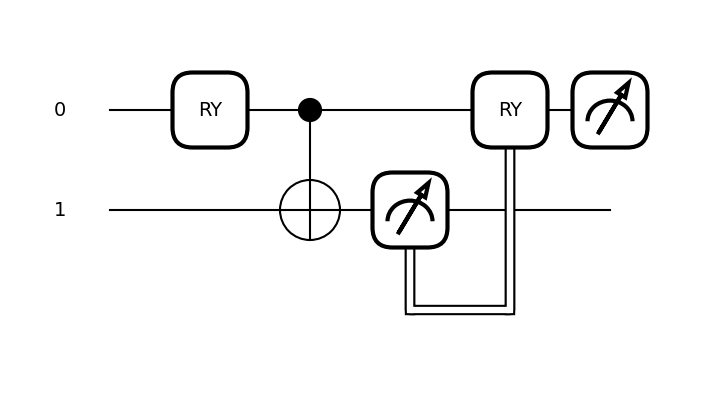

In [4]:
@qml.qnode(dev)
def circ2(x, y):
    qml.RY(x, 0)
    qml.CNOT([0,1])
    m_0=qml.measure(1)

    qml.cond(m_0==0, qml.RY)(y, 0)
    return qml.probs(wires=[0])

pars = np.array([0.643, 0.246], requires_grad=True)
print(circ2(*pars))

fig, ax = qml.draw_mpl(circ2)(*pars)
fig.show()

## Collecting statistics

PennyLane provides several terminal measurement statistics functions that can be used to analyze the outcomes of mid-circuit measurements: `counts()`, `expval()`, `probs()`, `sample()`, and `var()`. The following example shows the use of `probs()` to obtain the probabilities of the state of a wire and the outcome of a mid-circuit measurement.

/var/folders/ch/tk2fv32j3tg_jm9mf_b7rpbr0000gn/T/ipykernel_4485/3471954358.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


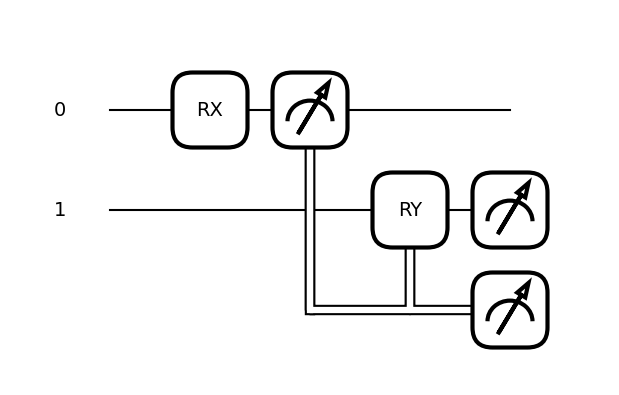

In [5]:
dev3 = qml.device("default.qubit")

@qml.qnode(dev3)
def circ3(x, y):
    qml.RX(x, 0)
    m_0 = qml.measure(0)
    qml.cond(m_0, qml.RY)(y, 1)
    return qml.probs(wires=1), qml.probs(op=m_0)

circ3(np.pi/2, np.pi/4)

fig, ax = qml.draw_mpl(circ3)(np.pi/2, np.pi/4)
fig.show()


* `qml.probs(wires=1)` gives the probability of wire 1 being in state $\ket{0}$ or $\ket{1}$ after the conditional `RY` operation
* `qml.probs(op=m_0)` gives the probabilities of the measurement outcome of `m_0` being 0 or 1

In [6]:
@qml.set_shots(10)
@qml.qnode(dev3)
def circ4(phi, theta):
    qml.RX(phi, wires=0)
    m_0 = qml.measure(wires=0)
    qml.RY(theta, wires=1)
    m_1 = qml.measure(wires=1)
    return qml.sample(~m_0 - 2 * m_1)

print(circ4(np.pi/2, np.pi/4))

qml.specs(circ4)(0,0)

[ 0  0  1  1  0  1  0  0  1 -2]


/Users/vegf/Desktop/vscode/pennylane/.venv/lib/python3.12/site-packages/pennylane/gradients/gradient_transform.py:290: UserWarning: Attempted to compute the gradient of a tape with no trainable parameters. If this is unintended, please mark trainable parameters in accordance with the chosen auto differentiation framework, or via the 'tape.trainable_params' property.
  warnings.warn(_no_trainable_grad_warning)


{'resources': Resources(num_wires=2, num_gates=4, gate_types=defaultdict(<class 'int'>, {'RX': 1, 'MidMeasureMP': 2, 'RY': 1}), gate_sizes=defaultdict(<class 'int'>, {1: 4}), depth=2, shots=Shots(total_shots=10, shot_vector=(ShotCopies(10 shots x 1),))),
 'errors': {},
 'num_observables': 1,
 'num_trainable_params': 0,
 'num_device_wires': 2,
 'num_tape_wires': 2,
 'device_name': 'default.qubit',
 'level': 'gradient',
 'gradient_options': {},
 'interface': 'auto',
 'diff_method': 'best',
 'gradient_fn': 'pennylane.gradients.parameter_shift.param_shift',
 'num_gradient_executions': 0}

0: ──RX(0.00)──┤↗├────────────────┤             
1: ─────────────║───RY(0.00)──┤↗├─┤             
                ╚══════════════║══╡ ╭Sample[MCM]
                               ╚══╡ ╰Sample[MCM]


Matplotlib is building the font cache; this may take a moment.
/var/folders/ch/tk2fv32j3tg_jm9mf_b7rpbr0000gn/T/ipykernel_4485/2291878018.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


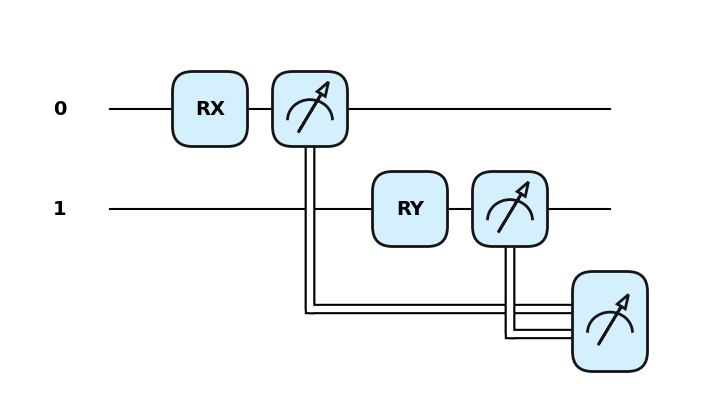

In [7]:
print(qml.draw(circ4)(0,0))

fig, ax= qml.draw_mpl(circ4, style='pennylane')(0,0)
fig.show()

In [8]:
@qml.qnode(dev)
def circ5():
    qml.H(0)
    qml.Snapshot("test")
    qml.H(0)
    return qml.state()

qml.snapshots(circ5)()

{'test': array([0.70710678+0.j, 0.        +0.j, 0.70710678+0.j, 0.        +0.j]),
 'execution_results': array([1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j])}

@qml.qnode(dev)
def circuit(x):
    qml.breakpoint()

    qml.RX(x, wires=0)
    qml.Hadamard(wires=1)

    qml.breakpoint()

    qml.CNOT(wires=[0, 1])
    return qml.expval(qml.Z(0))

circuit(1.23)